# DSA 5102 - Programming Assignment 1 (Solution)

## Description

As the first homework of this course, you will apply the knowledge you have learned in the first lecture on `linear models` and simple extensions using `kernel` methods on some datasets. This is also a chance to learn to use `jupyter notebook` and basic `sklearn` functionalities. A basic introduction to installing and using `jupyter notebooks` is found [here](https://www.datacamp.com/community/tutorials/tutorial-jupyter-notebook). You are strongly encouraged to use python 3 instead of python 2


The goals of this homework are
  * Learn basic data processing and machine learning using python
  * Reinforce knowledge on linear models and kernel methods
  * Prepare for the project in this course
  
Whenever you are stuck, you are encouraged to look at the jupyter notebook demonstration for the first lecture for some guidance. You should also learn to look at documentation of online libraries. For example, if you want to perform *kernel ridge regression* using `sklearn`, a quick google will land you on [this page](https://scikit-learn.org/stable/modules/kernel_ridge.html), where extensive description and examples are given.

## Instructions

Please complete each question below directly in this notebook. Note that you can write in the cells to describe what you are doing and any issues you face. If you are familiar, you can also format it using `markdown` as it is supported by `jupyter`. 

The grade given is based on the following
  1. Scientific correctness of your approach
  2. Clear documentation of your approach

## Dataset

We will work on the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy%2Befficiency) from the UCI Machine Learning Repository. The data describe 768 simulated residential building configurations. For this assignment, the goal is to predict **heating load** from eight building design properties:

1. `Relative_Compactness`
2. `Surface_Area`
3. `Wall_Area`
4. `Roof_Area`
5. `Overall_Height`
6. `Orientation`
7. `Glazing_Area`
8. `Glazing_Area_Distribution`

The original UCI dataset contains both heating-load and cooling-load responses. The supplied `energy_efficiency_heating.csv` retains the eight input variables and `Heating_Load` only, so the response is the last column. The dataset contains no missing values. Place the CSV file in the same folder as this notebook.

Dataset citation: Tsanas, A. & Xifara, A. (2012). *Energy Efficiency* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C51307](https://doi.org/10.24432/C51307). Licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('./energy_efficiency_heating.csv')

In [3]:
data.head(n=7)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71


## Question 1 (2 points)

In this homework we are going to predict the last column values (`Heating_Load`) from design variables in the other columns. Choose 3 input properties and visualize each of their effects on the heating load. Plot your findings below. You may find the `seaborn` library examples in lecture 1 useful.


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('notebook', font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.set_style("darkgrid")
np.random.seed(123)  # For reproducibility

Let us first visualize the dataset together to see some possible relationships.

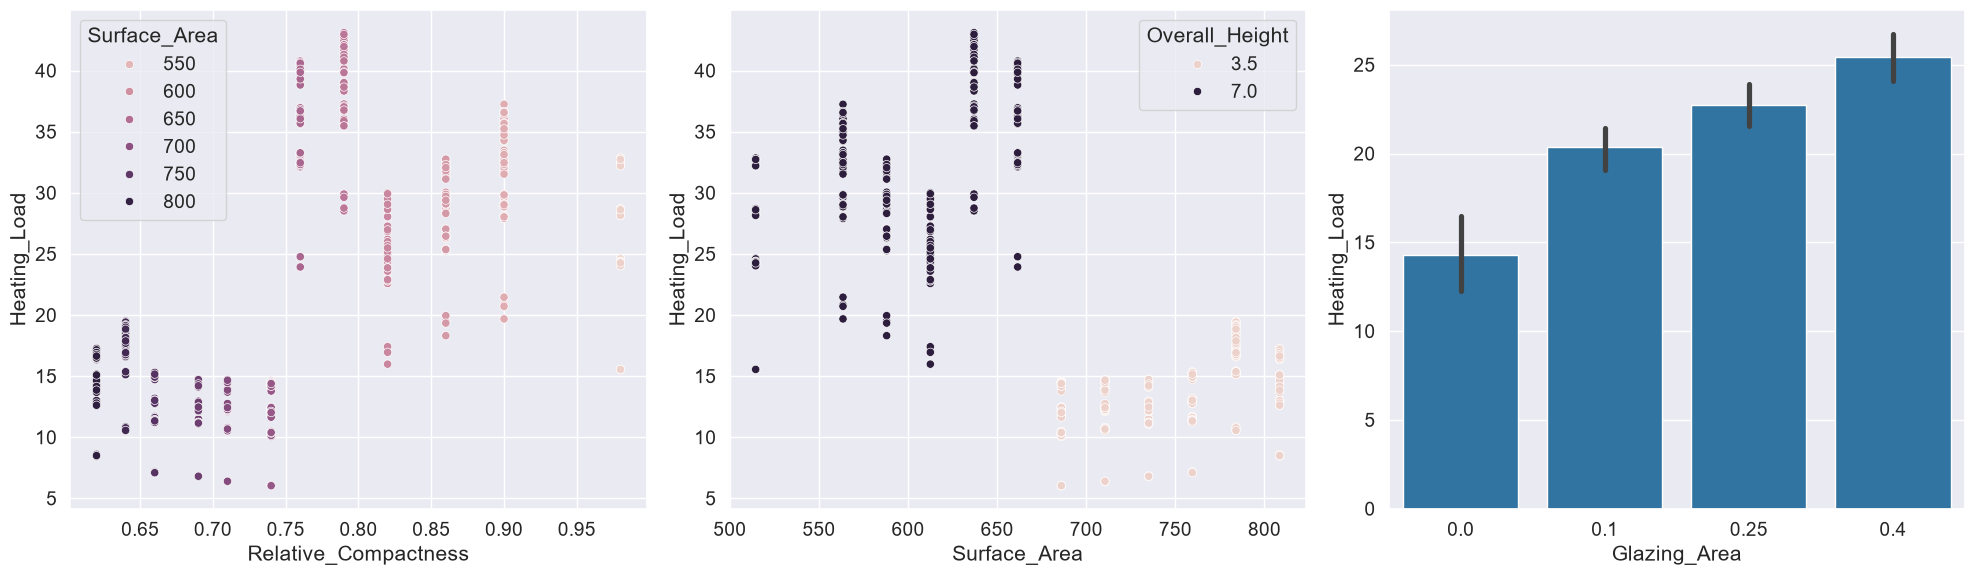

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    x='Relative_Compactness',
    y='Heating_Load',
    data=data,
    ax=ax[0],
    hue='Surface_Area',
)
sns.scatterplot(
    x='Surface_Area',
    y='Heating_Load',
    data=data,
    ax=ax[1],
    hue='Overall_Height',
)
sns.barplot(
    x='Glazing_Area',
    y='Heating_Load',
    data=data,
    ax=ax[2],
)

plt.tight_layout()
plt.show()

From the plots we can see that *Relative_Compactness* is positively correlated with *Heating_Load*. By coloring the scatter with *Surface_Area*, we also see that these two design properties are strongly related.

We confirm this by plotting *Surface_Area* against *Heating_Load*, which shows a decreasing relationship. The colors further suggest that taller buildings tend to have larger heating loads.

Finally, the bar plot shows that buildings with a nonzero *Glazing_Area* tend to have larger average heating loads than buildings without glazing. Notice that *Glazing_Area* is numerical but only takes a few specific values. We confirm this below by calling the `unique` method from `pandas`. As always, these plots show marginal associations; the inputs should be considered together in the regression models.

Different Glazing Area Values: [0.   0.1  0.25 0.4 ]


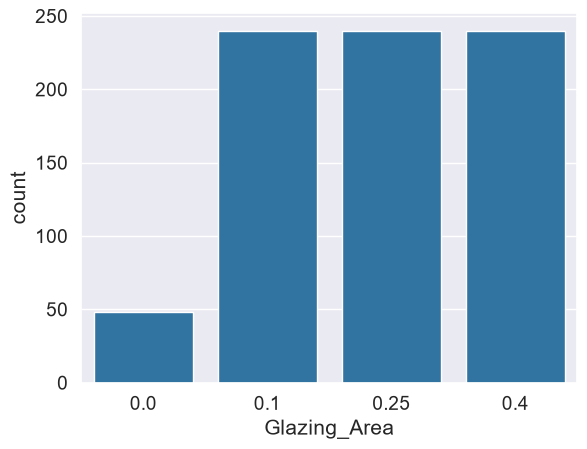

In [6]:
print('Different Glazing Area Values:', np.sort(data['Glazing_Area'].unique()))
sns.countplot(x='Glazing_Area', data=data)
plt.show()

# Question 2 (4 points)

Perform linear regression using all the input variables on this dataset to predict the heating load. Carefully evaluate your regression model using appropriate metrics and datasets.


## Train test split

In [7]:
from sklearn.model_selection import train_test_split

inputs = data.drop('Heating_Load', axis=1)
outputs = data['Heating_Load']

x_train, x_test, y_train, y_test = train_test_split(
    inputs,
    outputs,
    test_size=0.1,
    random_state=321,
)

## Linear Regression

Since we are going to compare the results over many regressors, it is handy to write a function to perform this evaluation so that we never have to write the same code twice. This is a very important rule of thumb in programming! If you are writing the same code twice, try to think how you can avoid doing so. This is crucial for code maintenance!

**Exercise**  
Now that you have seen cross-validation, try to modify the function below to output cross-validation scores.

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt


def scaled_rmse(y_true, y_pred):
    """
    Rescaled RMSE

    Parameters

        y_true: vector of labels
        y_pred: vector of predictions
    """
    mse = mean_squared_error(y_true, y_pred)
    return sqrt(mse / np.mean(y_true**2))


def score_model(model, data, metric):
    """
    Score model on data according to metric

    Parameters

        model: sklearn model instance
        data: tuple of inputs and labels
        metric: callable metric function metric(y_true, y_pred)
    """
    x, y_true = data
    y_pred = model.predict(x)
    return metric.__name__, metric(y_true, y_pred)


def train_and_evaluate(model,
                       train_data,
                       test_data,
                       metrics=[r2_score, mean_squared_error, scaled_rmse]):
    """
    Evaluates the train/test performance of model

    Parameters

        model: sklearn model instance
        train_data: tuple of training inputs and labels
        test_data: tuple of testing inputs and labels
        metrics: a list of callable metrics to evaluate
    """

    # Train model
    model.fit(*train_data)

    # Evaluate model
    print(f'{"="*100} \n Evaluating: \n {model} \n{"="*100}')
    results = {}
    for m in metrics:
        m_name, m_value_train = score_model(
            model=model,
            data=train_data,
            metric=m,
        )
        _, m_value_test = score_model(
            model=model,
            data=test_data,
            metric=m,
        )
        results[m_name] = {'train': m_value_train, 'test': m_value_test}
        print(
            f'{m_name:<20} {m_value_train:>10.2f} (train) '
            f'{m_value_test:>10.2f} (test)'
        )

    # Plot observed against predicted values
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    for a, (title, split_data) in zip(
        ax,
        [('Train', train_data), ('Test', test_data)],
    ):
        x, y_true = split_data
        y_pred = model.predict(x)
        sns.scatterplot(x=y_true, y=y_pred, ax=a, alpha=0.5)
        low = min(y_true.min(), y_pred.min())
        high = max(y_true.max(), y_pred.max())
        a.plot([low, high], [low, high], ls='--', c='k')
        a.set_title(title)
        a.set_xlabel('y_true')
        a.set_ylabel('y_pred')

    plt.tight_layout()
    plt.show()
    return results

## Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression

 Evaluating: 
 LinearRegression() 
r2_score                   0.92 (train)       0.91 (test)
mean_squared_error         8.39 (train)       9.74 (test)
scaled_rmse                0.12 (train)       0.12 (test)


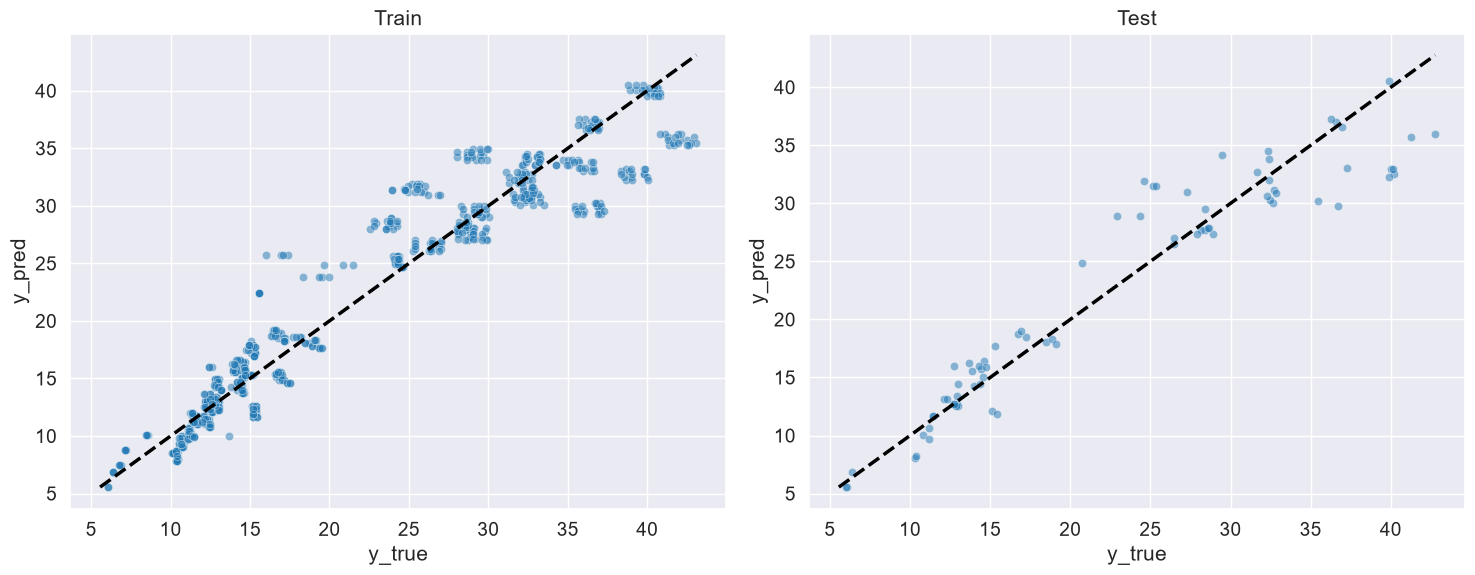

In [10]:
linear_regressor = LinearRegression()
linear_results = train_and_evaluate(
    model=linear_regressor,
    train_data=(x_train, y_train),
    test_data=(x_test, y_test),
)

The train and test results are close: the linear model obtains a test $R^2$ of about 0.91 and a test scaled RMSE of about 0.12. This indicates that the model generalizes similarly to the training data, although the scatter around the diagonal shows that a linear relationship does not capture all of the structure.

# Question 3 (4 points)

Now, instead of linear regression, apply kernel ridge regression (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)) with 3 kernels:
1. Linear kernel
2. Polynomial kernel with degree 3
3. RBF (Gaussian) kernel

Quantify the performance improvement (if any) with respect to the linear case, and also the other kernels. What do you observe? Which would you choose?

*Hint: For the RBF kernel, should you do something to the inputs first? Why?*

---

Note: we have not gone through cross validation and hyper-parameter tuning yet, so you are not expected to do this here -- although you are free to do it if you know how.


In [11]:
from sklearn.kernel_ridge import KernelRidge

## Linear Kernel

 Evaluating: 
 KernelRidge(alpha=0.1) 
r2_score                   0.91 (train)       0.91 (test)
mean_squared_error         8.62 (train)       9.85 (test)
scaled_rmse                0.12 (train)       0.13 (test)


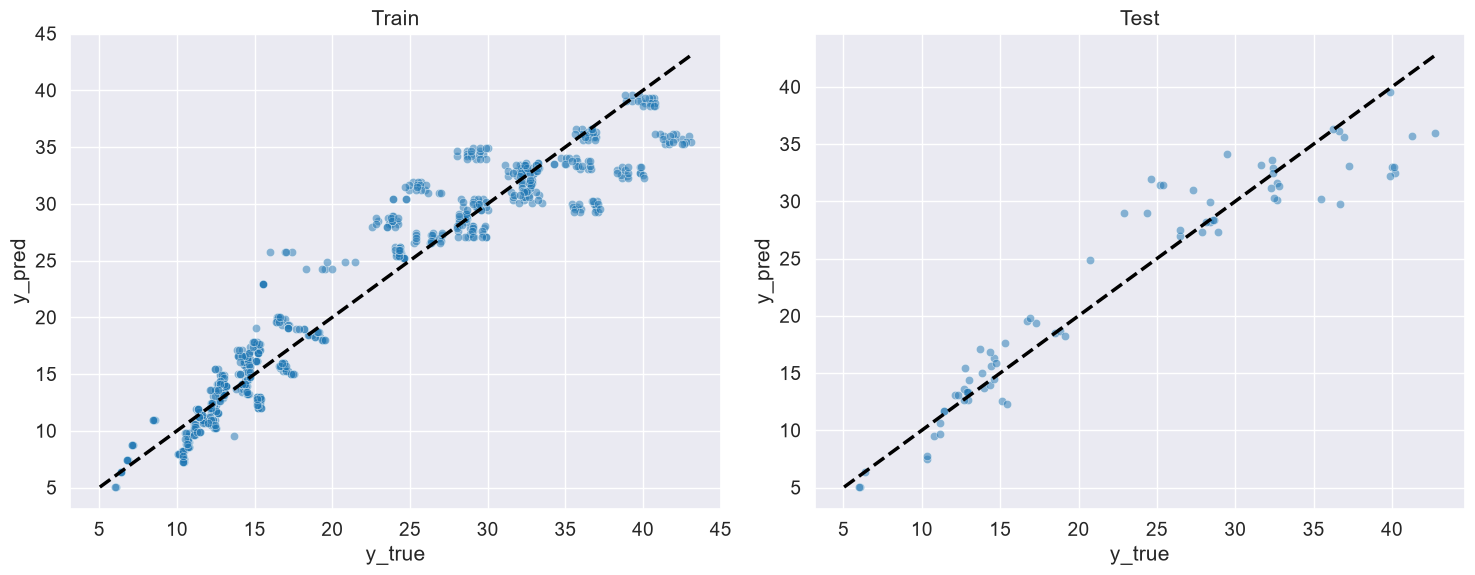

In [12]:
krr_linear = KernelRidge(kernel='linear', alpha=0.1)
krr_linear_results = train_and_evaluate(
    model=krr_linear,
    train_data=(x_train, y_train),
    test_data=(x_test, y_test),
)

## Polynomial (Degree 3) Kernel

 Evaluating: 
 KernelRidge(alpha=0.1, gamma=0.003, kernel='polynomial') 
r2_score                   0.99 (train)       0.99 (test)
mean_squared_error         0.92 (train)       0.80 (test)
scaled_rmse                0.04 (train)       0.04 (test)


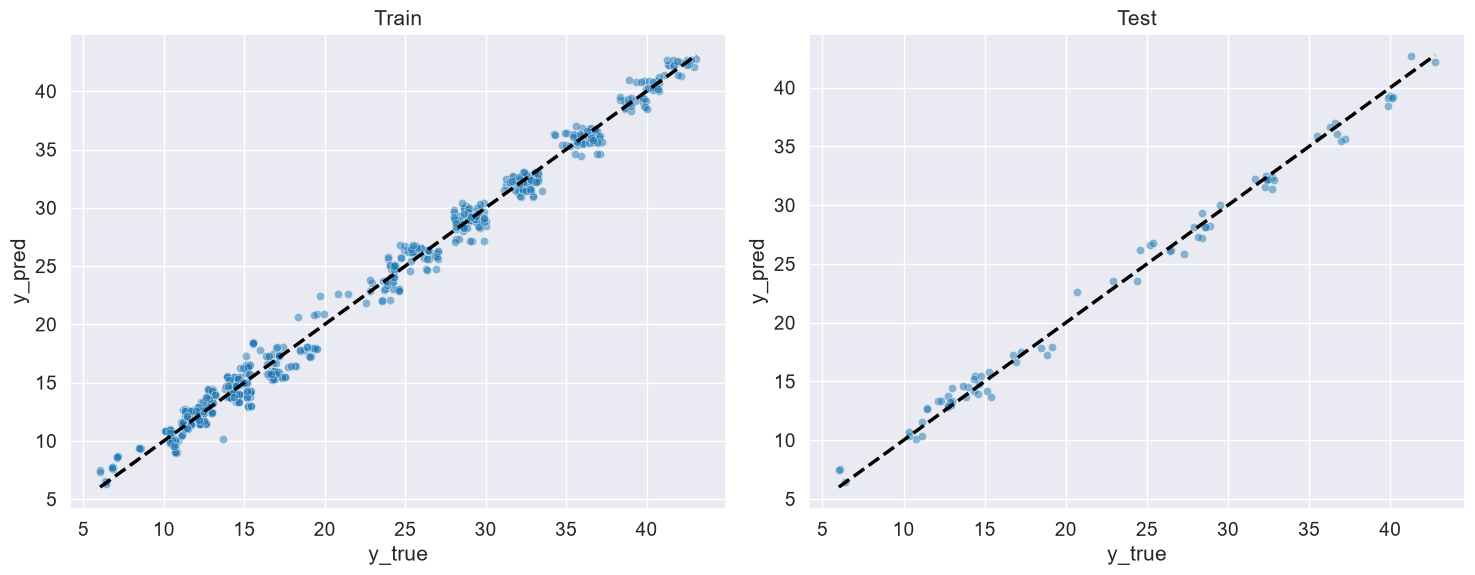

In [13]:
krr_poly3 = KernelRidge(
    kernel='polynomial',
    degree=3,
    alpha=0.1,
    gamma=0.003,
)
krr_poly3_results = train_and_evaluate(
    model=krr_poly3,
    train_data=(x_train, y_train),
    test_data=(x_test, y_test),
)

## RBF Kernel

RBF kernel has the form
$$
  k(x, x') = \exp(-\gamma \| x - x' \|^2).
$$
For $x$ with highly varying amplitudes, the kernel may become dominated by one coordinate, even if that coordinate does not correlate well with the output.

To resolve this, we typically want to normalize the inputs so that each coordinate of $x$ (corresponding to each feature) is roughly of the same order. We can use `sklearn.preprocessing.MinMaxScaler` to achieve this, although there are many other options in the [`sklearn.preprocessing`](https://scikit-learn.org/stable/modules/preprocessing.html) module. The scaler works by transforming the inputs $x$ to
$$
    x \mapsto \frac{x-x_{min}}{x_{max} - x_{min}},
$$
where $x_{min}$ (resp. $x_{max}$) is a vector of min (resp. max) values of $x$ across the training set. It is important to fit the scaler on the training data only, then apply the same transformation to the test data.

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)

 Evaluating: 
 KernelRidge(alpha=0.01, gamma=2.0, kernel='rbf') 
r2_score                   1.00 (train)       0.99 (test)
mean_squared_error         0.27 (train)       0.61 (test)
scaled_rmse                0.02 (train)       0.03 (test)


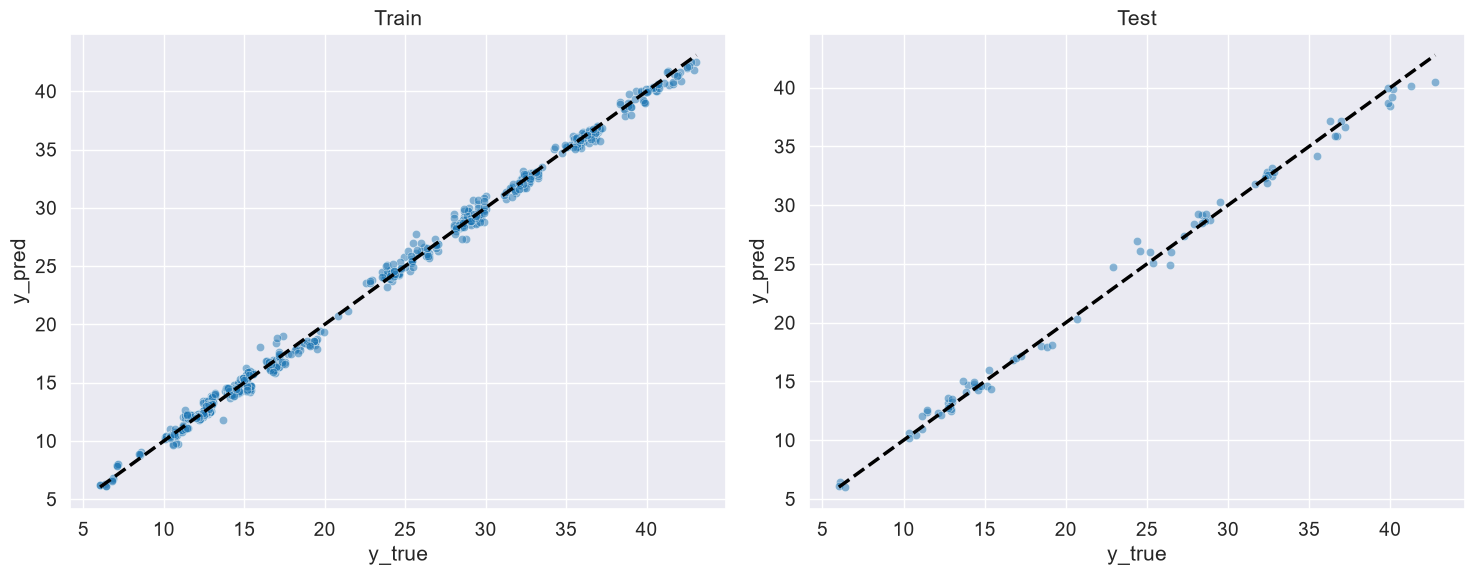

In [15]:
krr_rbf = KernelRidge(kernel='rbf', alpha=0.01, gamma=2.0)

krr_rbf_results = train_and_evaluate(
    model=krr_rbf,
    train_data=(x_train_normalized, y_train),
    test_data=(x_test_normalized, y_test),
)

I have done some slight hand tuning of the parameters. To achieve optimal performance, you should use *cross-validation* like we have introduced in the lectures.

From the simple experiments above, KRR with the RBF kernel gives the best test performance: test $R^2$ is about 0.997 and scaled RMSE is about 0.03. The degree-3 polynomial kernel is close, with test $R^2$ around 0.993 and scaled RMSE around 0.04. The linear kernel has test $R^2$ around 0.91 and scaled RMSE around 0.13.

Using the unrounded values, the polynomial and RBF kernels reduce test scaled RMSE by approximately 71.5% and 75.1%, respectively, relative to Linear KRR. RBF is about 12.6% lower than the polynomial result. I would therefore choose RBF among these particular models, while noting that careful cross-validation could change the ranking. You should also try whether normalization helps the other kernels.